# Homework B Coding Question

This notebook contains the source code for Question 1. It samples the prior, performs the Bayes update, and plots the prior and posterior histograms.

Prior mean: -0.001417385265726449
Prior std : 1.228160556730051
Posterior mean: 0.30097877974071385
Posterior std : 0.38963310024548814


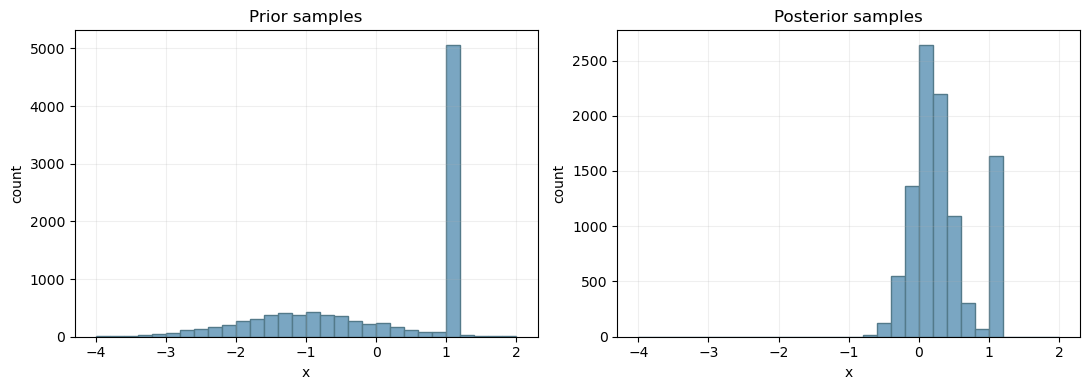

In [1]:
import math

import matplotlib.pyplot as plt
import numpy as np


def sample_prior(n, seed=42):
    rng = np.random.default_rng(seed)
    choose_point_mass = rng.random(n) < 0.5
    samples = np.empty(n)
    samples[choose_point_mass] = 1.0
    samples[~choose_point_mass] = rng.normal(loc=-1.0, scale=1.0, size=(~choose_point_mass).sum())
    return samples


def gaussian_pdf(x, mean, var):
    coeff = 1.0 / math.sqrt(2.0 * math.pi * var)
    return coeff * np.exp(-0.5 * (x - mean) ** 2 / var)


def likelihood(z, x, var=0.3):
    return gaussian_pdf(z, 2.0 * x, var)


def sample_posterior(prior_samples, z=0.5, seed=43):
    rng = np.random.default_rng(seed)
    weights = likelihood(z, prior_samples)
    weights /= weights.sum()
    indices = rng.choice(len(prior_samples), size=len(prior_samples), p=weights)
    return prior_samples[indices]


prior = sample_prior(10_000, seed=42)
posterior = sample_posterior(prior, z=0.5, seed=43)

print("Prior mean:", prior.mean())
print("Prior std :", prior.std())
print("Posterior mean:", posterior.mean())
print("Posterior std :", posterior.std())


fig, axes = plt.subplots(1, 2, figsize=(11, 4))
bins = np.linspace(-4, 2, 31)
axes[0].hist(prior, bins=bins, color="#7aa6c2", edgecolor="#537a8a")
axes[0].set_title("Prior samples")
axes[0].set_xlabel("x")
axes[0].set_ylabel("count")
axes[0].grid(alpha=0.2)

axes[1].hist(posterior, bins=bins, color="#7aa6c2", edgecolor="#537a8a")
axes[1].set_title("Posterior samples")
axes[1].set_xlabel("x")
axes[1].set_ylabel("count")
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()
